In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from response_generator.pipeline import *

import sys
import os

from matplotlib import font_manager as fm
from matplotlib import rc


from pathlib import Path
import itertools

import numpy as np
import pandas as pd
from tqdm import tqdm

from response_generator.pipeline import SimulationConfig, ResponseSimulator, _force_matlab_cell_structure, _parse_save_by_language, _as_cell_of_scalars, _as_numeric_vector, _is_sequence, _as_cell_of_vectors
from response_generator.generators import PoissonSpikeGenerator

from response_generator.plot_utils import *

from scipy.ndimage import gaussian_filter

rng = np.random.default_rng()

# set global font to be Helvetica
helvetica_path = os.path.join('fonts', 'Helvetica.ttf')
font_prop = fm.FontProperties(fname=helvetica_path)
print("Loaded font name:", font_prop.get_name())
fm.fontManager.addfont(helvetica_path)
rc('font', family=font_prop.get_name())

save_dir = Path("plots")

Loaded font name: Helvetica


In [29]:
parent = Path("/media/al/darch/response_stats/datasets/bursts/")

response_parquet = []

for item in parent.iterdir():
    file_ = list(item.glob("*.parquet"))
    response_parquet.append(file_[0])

df = pd.read_parquet(response_parquet)
df = df[df["response"] == '1']

In [31]:
baseline_fr_dist = df["fr_baseline"]
response_fr_dist = df["fr_response"]

latencies = df["latency"]
durations = df["duration"]

beta_a = df["beta_a"]
beta_b = df["beta_b"]

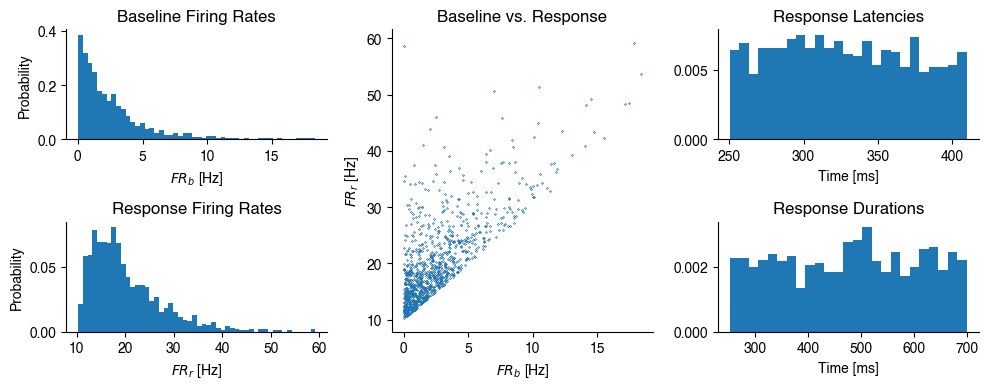

In [37]:
axes = plt.figure( figsize=(10, 4)).subplot_mosaic(
    """
    ACD
    BCE
    """
)

ax = axes["A"]
ax.hist(baseline_fr_dist, bins=50, density=True)
#ax.vlines(np.mean(baseline_fr_dist), ax.get_ylim()[0], ax.get_ylim()[1], lw=2, color="tab:orange",)
#ax.text(np.mean(baseline_fr_dist) + 1, 0.4, f"mean: {round(np.mean(baseline_fr_dist), 3)}")
ax.set_title("Baseline Firing Rates")
ax.set_xlabel(r"$FR_b$ [Hz]")
ax.set_ylabel("Probability")

ax = axes["B"]
ax.hist(response_fr_dist, bins=50, density=True)
ax.set_title("Response Firing Rates")
ax.set_xlabel(r"$FR_r$ [Hz]")
ax.set_ylabel("Probability")

ax = axes["C"]
ax.scatter(baseline_fr_dist, response_fr_dist, s=0.01, alpha=0.5)
ax.set_xlabel(r"$FR_b$ [Hz]")
ax.set_ylabel(r"$FR_r$ [Hz]")
ax.set_title("Baseline vs. Response")

ax = axes["D"]
ax.hist(latencies * 1000, bins=25, density=True)
ax.set_title("Response Latencies")
ax.set_xlabel("Time [ms]")

ax = axes["E"]
ax.hist(durations * 1000, bins=25, density=True)
ax.set_title("Response Durations")
ax.set_xlabel("Time [ms]")

sns.despine()   

plt.tight_layout()

plt.savefig(save_dir / "simulation_params_1.svg", dpi=200,bbox_inches="tight")

plt.show()

In [38]:
baseline_fr = 2
response_fr = 20

duration = 0.5
latency = 0.3



burst_rate_baseline = 0.5
burst_rate_factor   = 0.25
burst_rate_response = 15.




a = 1.
b = 1.6
generator = PoissonSpikeGenerator(
baseline_fr=baseline_fr,
response_fr=response_fr,
latency=latency,
duration=duration,
baseline_T=2,
stimulus_T=2,
dt=0.001,
induce_refractory_period=True,
rng=rng,
a=a,
b=b, 
include_bursts=False, 
        burst_rate_baseline=burst_rate_baseline, 
        burst_rate_factor=burst_rate_factor,
        burst_rate_response=burst_rate_response, 
        burst_response_time_factor=5, 
        # trial-wise burst params
        burst_duration_lam=150,
        burst_alpha=1.5, 
        burst_beta=3,
        burst_multiplier=10,
)
rt1 = generator.r_t




a = 1.25
b = 2.2
generator = PoissonSpikeGenerator(
baseline_fr=baseline_fr,
response_fr=response_fr,
latency=latency,
duration=duration,
baseline_T=2,
stimulus_T=2,
dt=0.001,
induce_refractory_period=True,
rng=rng,
a=a,
b=b, 
include_bursts=False, 
        burst_rate_baseline=burst_rate_baseline, 
        burst_rate_factor=burst_rate_factor,
        burst_rate_response=burst_rate_response, 
        burst_response_time_factor=5, 
        # trial-wise burst params
        burst_duration_lam=150,
        burst_alpha=1.5, 
        burst_beta=3,
        burst_multiplier=10,
)
rt2 = generator.r_t



a = 1.5
b = 2.8
generator = PoissonSpikeGenerator(
baseline_fr=baseline_fr,
response_fr=response_fr,
latency=latency,
duration=duration,
baseline_T=2,
stimulus_T=2,
dt=0.001,
induce_refractory_period=True,
rng=rng,
a=a,
b=b, 
include_bursts=False, 
        burst_rate_baseline=burst_rate_baseline, 
        burst_rate_factor=burst_rate_factor,
        burst_rate_response=burst_rate_response, 
        burst_response_time_factor=5, 
        # trial-wise burst params
        burst_duration_lam=150,
        burst_alpha=1.5, 
        burst_beta=3,
        burst_multiplier=10,
)
rt3 = generator.r_t

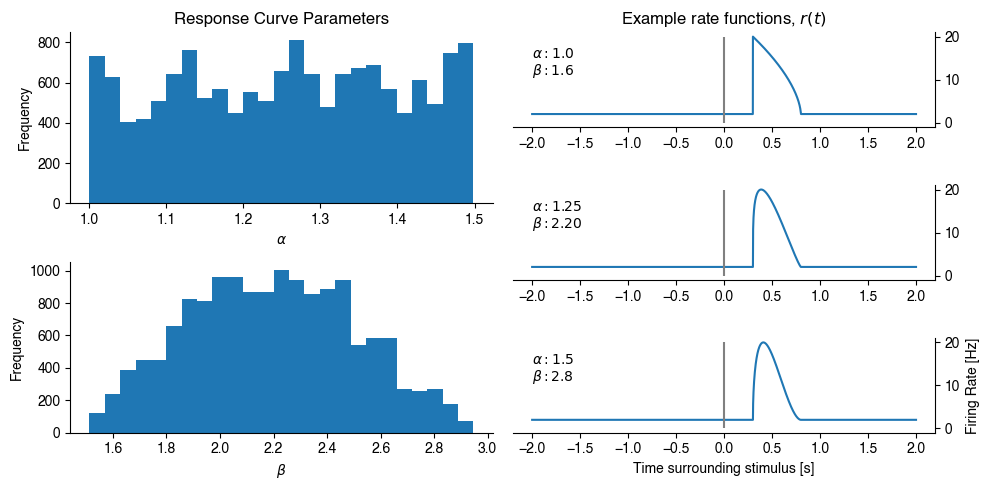

In [42]:
axes = plt.figure( figsize=(10, 5)).subplot_mosaic(
    """
    AACC
    AACC
    AADD
    BBDD
    BBEE
    BBEE
    """
)

ax = axes["A"]
ax.hist(beta_a, bins=25,)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("Frequency")
ax.set_title("Response Curve Parameters")

ax = axes["B"]
ax.hist(beta_b, bins=25, )
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Frequency")

x = np.linspace(-2, 2, 4000)

ax = axes["C"]
ax.plot(x, rt1)
ax.text(-2, 15, r"$\alpha: 1.0$")
ax.text(-2, 11, r"$\beta:  1.6$")
ax.set_title(r"Example rate functions, $r(t)$")

ax = axes["D"]
ax.plot(x, rt2)
ax.text(-2, 15, r"$\alpha: 1.25$")
ax.text(-2, 11, r"$\beta:  2.20$")

ax = axes["E"]
ax.plot(x, rt3)
ax.text(-2, 15, r"$\alpha: 1.5$")
ax.text(-2, 11, r"$\beta:  2.8$")
ax.set_xlabel("Time surrounding stimulus [s]")
ax.set_ylabel("Firing Rate [Hz]")


for key in ["A", "B"]:
    ax = axes[key]
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


for key in ["C", "D", "E"]:
    ax = axes[key]
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)  # remove left spine
    ax.spines["right"].set_visible(True)  # keep right spine
    ax.vlines(0, 0, 20,  color="grey")

plt.tight_layout()

plt.savefig(save_dir / "simulation_params_2.svg", dpi=100,bbox_inches="tight")


plt.show()


In [3]:
def get_bursts_and_also_not_bursts(baseline_fr, response_fr, a, b):
        
        burst_rate_baseline = 0.5
        burst_rate_factor   = 0.25
        burst_rate_response = 15.       

        duration = 0.5
        latency = 0.3


        rng = np.random.default_rng(seed=73)

        generator = PoissonSpikeGenerator(
        baseline_fr=baseline_fr,
        response_fr=response_fr,
        latency=latency,
        duration=duration,
        baseline_T=2,
        stimulus_T=2,
        dt=0.001,
        induce_refractory_period=True,
        rng=rng,
        a=a,
        b=b, 
        include_bursts=False, 
                burst_rate_baseline=burst_rate_baseline, 
                burst_rate_factor=burst_rate_factor,
                burst_rate_response=burst_rate_response, 
                burst_response_time_factor=5, 
                # trial-wise burst params
                burst_duration_lam=150,
                burst_alpha=1.5, 
                burst_beta=3,
                burst_multiplier=10,
        debug=True,
        )

        n_trials = 10

        trial_activity = generator.generate(n_trials)
        trial_activity = [t - 2 for t in trial_activity]

        burst_rate_baseline = 0.5
        burst_rate_factor   = 0.25
        burst_rate_response = 15.

        rng = np.random.default_rng(seed=73)


        generator_b = PoissonSpikeGenerator(
        baseline_fr=baseline_fr,
        response_fr=response_fr,
        latency=latency,
        duration=duration,
        baseline_T=2,
        stimulus_T=2,
        dt=0.001,
        induce_refractory_period=True,
        rng=rng,
        a=a,
        b=b, 
        include_bursts=True, 
                burst_rate_baseline=burst_rate_baseline, 
                burst_rate_factor=burst_rate_factor,
                burst_rate_response=burst_rate_response, 
                burst_response_time_factor=5, 
                # trial-wise burst params
                burst_duration_lam=150,
                burst_alpha=1.5, 
                burst_beta=3,
                burst_multiplier=10,
        debug=True,
        )

        n_trials = 10

        trial_activity_b = generator_b.generate(n_trials)
        trial_activity_b = [t - 2 for t in trial_activity_b]

        return generator, trial_activity, generator_b, trial_activity_b

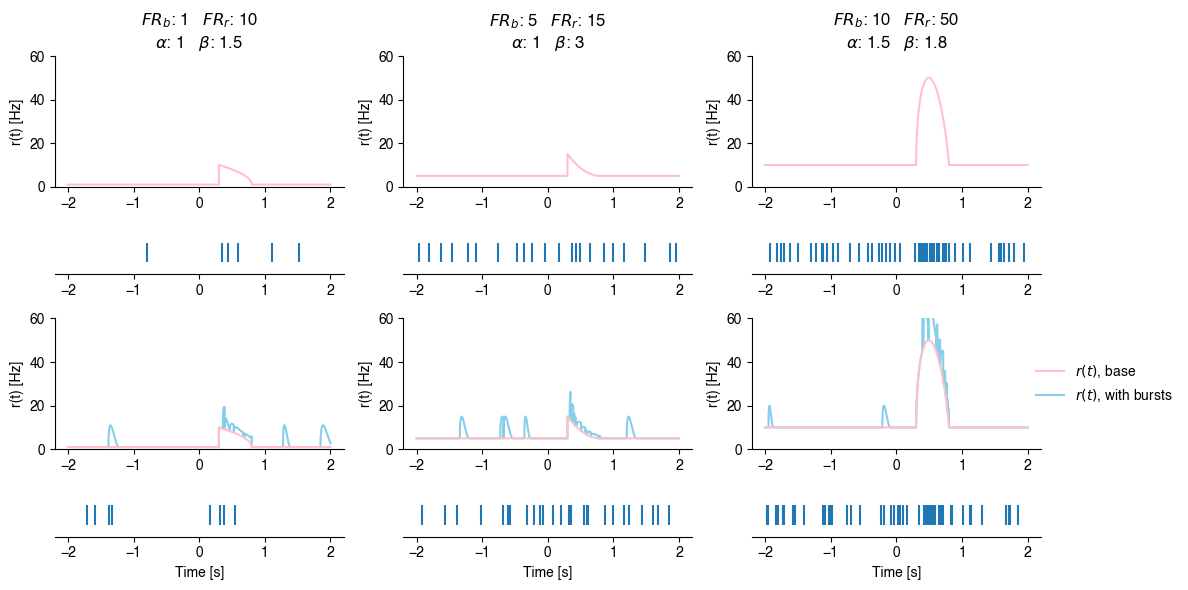

In [7]:
axes = plt.figure( figsize=(12, 6)).subplot_mosaic(
    """
    AACCEE
    AACCEE
    BBDDFF
    GGIIKK
    GGIIKK
    HHJJLL
    """
)


x = np.linspace(-2, 2, 4000)

b = r"$FR_b$"
r = r"$FR_r$"

beta_a = r"$\alpha$"
beta_b = r"$\beta$"

######
baseline_fr = 1
response_fr = 10
a = 1
b_ = 1.5
generator, trial_activity, generator_b, trial_activity_b = get_bursts_and_also_not_bursts(baseline_fr, response_fr, a, b_)

ax = axes["A"]
i = 0
ax.plot(x, generator.r_t, color="pink")
#ax.set_yticks([0, 5, 10])
ax.set_ylabel(r"r(t) [Hz]")
ax.set_title(f"{b}: {baseline_fr}   {r}: {response_fr}\n{beta_a}: {a}   {beta_b}: {b_}")
sns.despine(ax=ax)

ax = axes["B"]
ax.sharex(axes['A'])
ax.eventplot(trial_activity[i])
ax.set_yticks([])
sns.despine(left=True, ax=ax)


### bursts
ax = axes["G"]
ax.sharex(axes['A'])

ax.plot(x, generator_b.burst_r_t_collection[i], color="skyblue")
ax.plot(x, generator_b.r_t, color="pink")
ax.set_ylabel(r"r(t) [Hz]")
sns.despine(ax=ax)

ax = axes["H"]
ax.sharex(axes['A'])
ax.eventplot(trial_activity_b[i])
ax.set_yticks([])
sns.despine(left=True, ax=ax)
ax.set_xlabel("Time [s]")


######
baseline_fr = 5
response_fr = 15
a = 1
b_ = 3
generator, trial_activity, generator_b, trial_activity_b = get_bursts_and_also_not_bursts(baseline_fr, response_fr, a, b_)

ax = axes["C"]
i = 2
ax.plot(x, generator.r_t, color="pink")
ax.set_ylabel(r"r(t) [Hz]")
ax.set_title(f"{b}: {baseline_fr}   {r}: {response_fr}\n{beta_a}: {a}   {beta_b}: {b_}")
sns.despine(ax=ax)

ax = axes["D"]
ax.sharex(axes['A'])
ax.eventplot(trial_activity[i])
ax.set_yticks([])
sns.despine(left=True, ax=ax)


### bursts
ax = axes["I"]
ax.sharex(axes['A'])

ax.plot(x, generator_b.burst_r_t_collection[i], color="skyblue")
ax.plot(x, generator_b.r_t, color="pink")
ax.set_ylabel(r"r(t) [Hz]")
sns.despine(ax=ax)

ax = axes["J"]
ax.sharex(axes['A'])
ax.eventplot(trial_activity_b[i])
ax.set_yticks([])
sns.despine(left=True, ax=ax)
ax.set_xlabel("Time [s]")



######
baseline_fr = 10
response_fr = 50
a = 1.5
b_ = 1.8
generator, trial_activity, generator_b, trial_activity_b = get_bursts_and_also_not_bursts(baseline_fr, response_fr, a, b_)

ax = axes["E"]
i = 1
ax.plot(x, generator.r_t, color="pink")
ax.set_ylabel(r"r(t) [Hz]")
ax.set_title(f"{b}: {baseline_fr}   {r}: {response_fr}\n{beta_a}: {a}   {beta_b}: {b_}")
sns.despine(ax=ax)

ax = axes["F"]
ax.sharex(axes['A'])
ax.eventplot(trial_activity[i])
ax.set_yticks([])
sns.despine(left=True, ax=ax)


### bursts
ax = axes["K"]
ax.sharex(axes['A'])

ax.plot(x, generator_b.burst_r_t_collection[i], color="skyblue", label=r"$r(t)$, with bursts")
ax.plot(x, generator_b.r_t, color="pink", label=r"$r(t)$, base")
ax.set_ylabel(r"r(t) [Hz]")
sns.despine(ax=ax)


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], frameon=False,
          loc="center right", bbox_to_anchor=(1.5, 0.5))


ax = axes["L"]
ax.sharex(axes['A'])
ax.eventplot(trial_activity_b[i])
ax.set_yticks([])
sns.despine(left=True, ax=ax)
ax.set_xlabel("Time [s]")

for key, ax in axes.items():
    if key in ["A", "C", "E", "G", "I", "K"]:
        ax.set_ylim(0, 60)

plt.tight_layout()

plt.savefig(save_dir / "simulation_params_3.svg", dpi=100,bbox_inches="tight")
plt.savefig(save_dir / "SFig_SimulationParams3.png", dpi=100,bbox_inches="tight")  